# imports

In [1]:
import pymc as pm
import numpy as np
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.gaussian_process as gp
from sklearn.model_selection import train_test_split

In [9]:
def plot_pred(mu, sigma):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_ylim(-1.25, 1.75)

    plt.fill_between(Xnew.flatten(), mu - sigma, mu + sigma, alpha=.2, color='black')
    plt.plot(Xnew.flatten(), mu, color='black')
    plt.scatter(X, y, s=20, c='tab:red', zorder=10)

In [13]:
def plot_samples(trace):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_ylim(-1.25, 1.75)

    plt.scatter(X, y, s=20, c='tab:red', zorder=10)
    for sample in trace:
        plt.plot(Xnew.flatten(), sample, lw=.2, alpha=.01, c='b')

# data

In [2]:
np.random.seed(0)
X = np.random.uniform(0, 5, 10)[:, None]
y = np.sin((X - 2.5) ** 2) # + np.random.normal(scale=.1, size=25)[:, None]

Xnew = np.linspace(0, 5, 1000)[:, None]

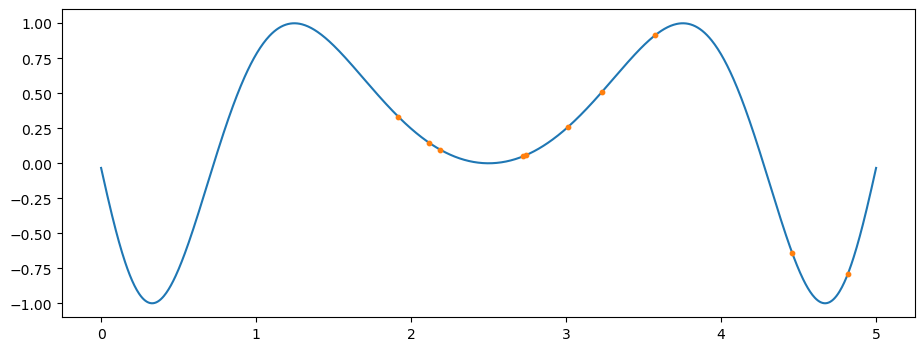

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
plt.plot(Xnew, np.sin((Xnew - 2.5) ** 2))
plt.scatter(X, y, s=10, c='tab:orange', zorder=10)

# sklearn

In [5]:
sk_kernel = gp.kernels.RBF(length_scale=1, length_scale_bounds=(1e-2, 1e2))
sk_model = gp.GaussianProcessRegressor(kernel=sk_kernel, n_restarts_optimizer=10)
sk_model.fit(X, y)

GaussianProcessRegressor(kernel=RBF(length_scale=1), n_restarts_optimizer=10)

In [8]:
sk_mean, sk_std = sk_model.predict(Xnew, return_std=True)
sk_model.kernel_

RBF(length_scale=0.609)

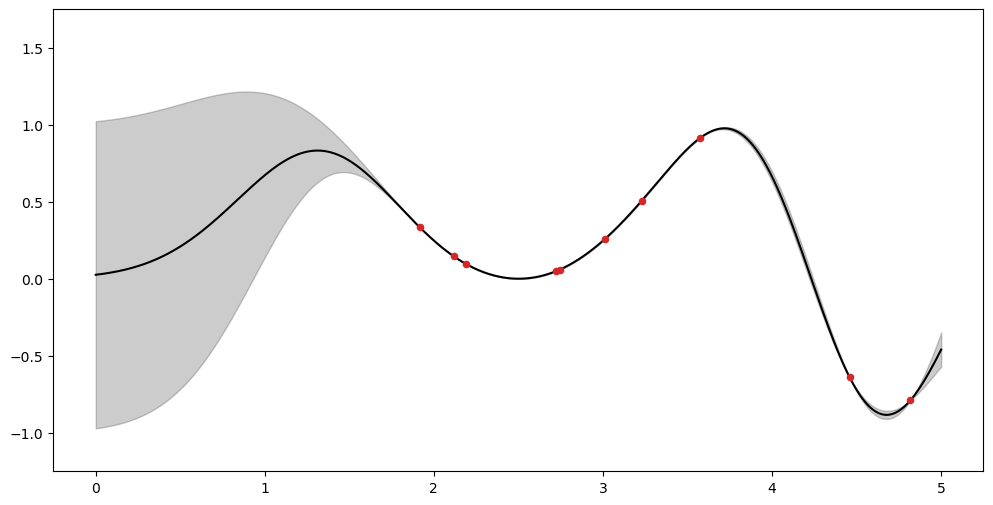

In [10]:
plot_pred(sk_mean, sk_std)

# pymc

In [11]:
with pm.Model() as model:
    ls = pm.Uniform('ls', lower=1e-2, upper=1e2)
    
    cov_func = pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    pm_gp = pm.gp.Marginal(cov_func=cov_func)

    f = pm_gp.marginal_likelihood('f', X, y.flatten(), sigma=0)

In [12]:
with model:
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ls]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 714 seconds.


array([[<AxesSubplot:title={'center':'ls'}>,
        <AxesSubplot:title={'center':'ls'}>]], dtype=object)

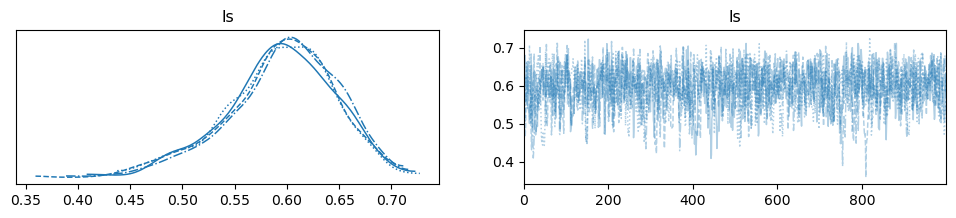

In [39]:
az.plot_trace(idata)

In [15]:
with model:
    cond = pm_gp.conditional('cond', Xnew)
    pp = pm.sample_posterior_predictive(idata.posterior, var_names=['cond'])

Sampling: [cond]


In [16]:
ynew = np.array(pp.posterior_predictive.variables['cond']).reshape(4000, 1000)
pm_mean = ynew.mean(axis=0)
pm_std = ynew.std(axis=0)

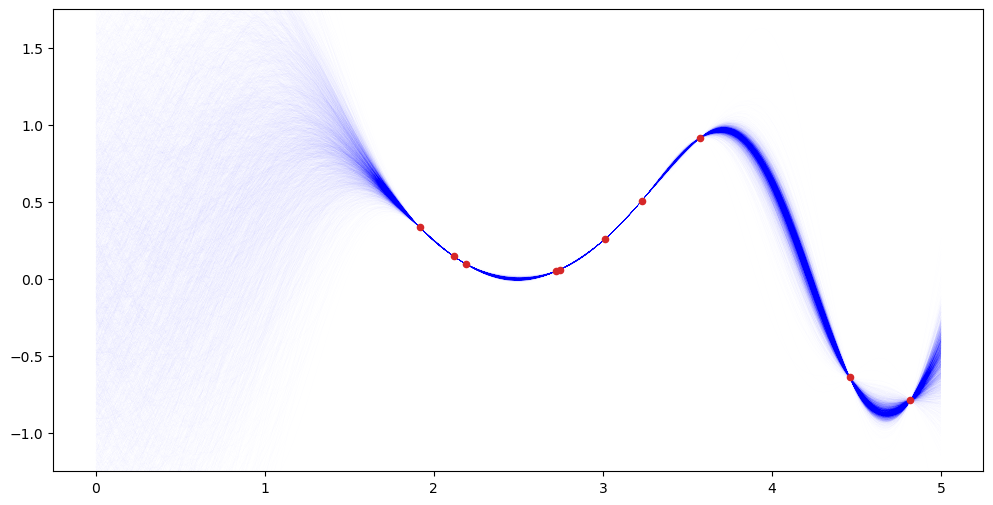

In [17]:
plot_samples(ynew)

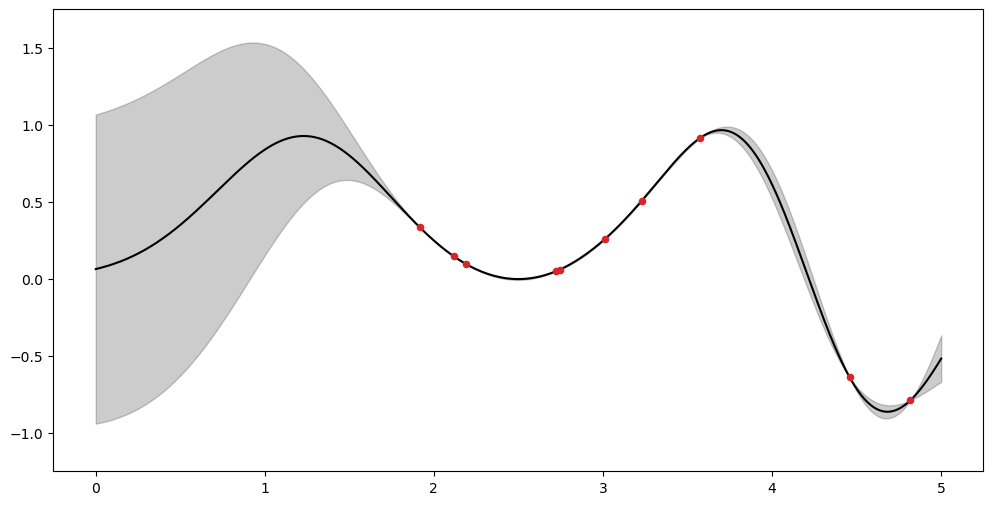

In [18]:
plot_pred(pm_mean, pm_std)

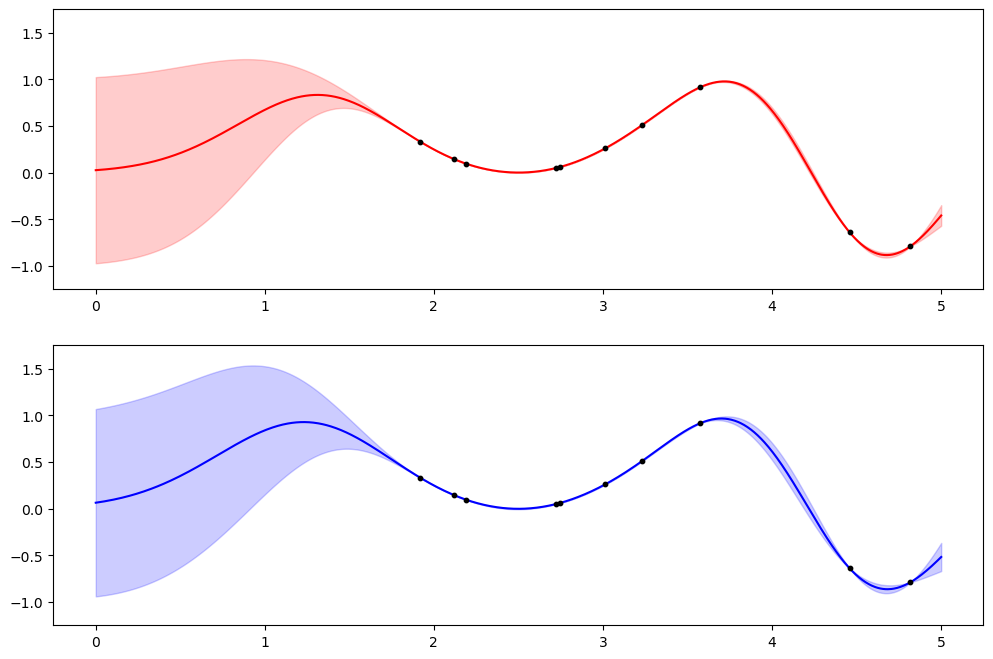

In [27]:
fig, (ax_sk, ax_pm) = plt.subplots(2, 1, figsize=(12, 8))
ax_sk.set_ylim(-1.25, 1.75)
ax_pm.set_ylim(-1.25, 1.75)

ax_sk.fill_between(Xnew.flatten(), sk_mean - sk_std, sk_mean + sk_std, alpha=.2, color='red')
ax_sk.plot(Xnew.flatten(), sk_mean, color='red')
ax_sk.scatter(X, y, s=10, c='black', zorder=10)

ax_pm.fill_between(Xnew.flatten(), pm_mean - pm_std, pm_mean + pm_std, alpha=.2, color='blue')
ax_pm.plot(Xnew.flatten(), pm_mean, color='blue')
ax_pm.scatter(X, y, s=10, c='black', zorder=10)

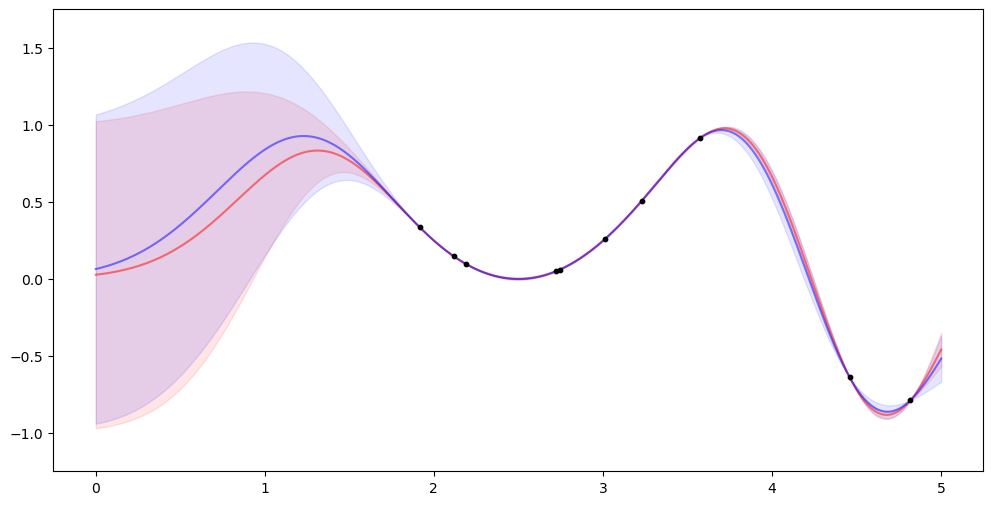

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(-1.25, 1.75)
plt.scatter(X, y, s=10, c='black', zorder=10)

ax.fill_between(Xnew.flatten(), sk_mean - sk_std, sk_mean + sk_std, alpha=.1, color='red')
ax.plot(Xnew.flatten(), sk_mean, alpha=.5, color='red')

ax.fill_between(Xnew.flatten(), pm_mean - pm_std, pm_mean + pm_std, alpha=.1, color='blue')
ax.plot(Xnew.flatten(), pm_mean, alpha=.5, color='blue')


# pymc approximation

In [67]:
with pm.Model() as approx_model:
    ls = pm.Uniform('ls', lower=1e-2, upper=1e2)
    
    cov_func = pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    gp = pm.gp.MarginalApprox(cov_func=cov_func)

    f = gp.marginal_likelihood('f', X=X, Xu=np.linspace(0, 5, 5)[:, None], y=y.flatten(), sigma=0)

In [68]:
with approx_model:
    idata = pm.sample()

/Users/artembadmaev/miniconda3/envs/pymcenv/lib/python3.9/site-packages/aesara/tensor/rewriting/math.py:1068: RuntimeWarning: divide by zero encountered in double_scalars
  v = reduce(np.multiply, num, one) / reduce(np.multiply, denum, one)
/Users/artembadmaev/miniconda3/envs/pymcenv/lib/python3.9/site-packages/aesara/tensor/rewriting/math.py:1068: RuntimeWarning: divide by zero encountered in divide
  v = reduce(np.multiply, num, one) / reduce(np.multiply, denum, one)
/Users/artembadmaev/miniconda3/envs/pymcenv/lib/python3.9/site-packages/aesara/tensor/rewriting/math.py:1068: RuntimeWarning: divide by zero encountered in double_scalars
  v = reduce(np.multiply, num, one) / reduce(np.multiply, denum, one)
/Users/artembadmaev/miniconda3/envs/pymcenv/lib/python3.9/site-packages/aesara/tensor/rewriting/math.py:1068: RuntimeWarning: divide by zero encountered in divide
  v = reduce(np.multiply, num, one) / reduce(np.multiply, denum, one)
/Users/artembadmaev/miniconda3/envs/pymcenv/lib/pyth

KeyboardInterrupt: 

In [13]:
with approx_model:
    cond = gp.conditional('cond', Xnew)
    pp = pm.sample_posterior_predictive(idata.posterior, var_names=['cond'])

In [10]:
ynew = np.array(pp.posterior_predictive.variables['cond'])
ynew.shape

NameError: name 'pp' is not defined

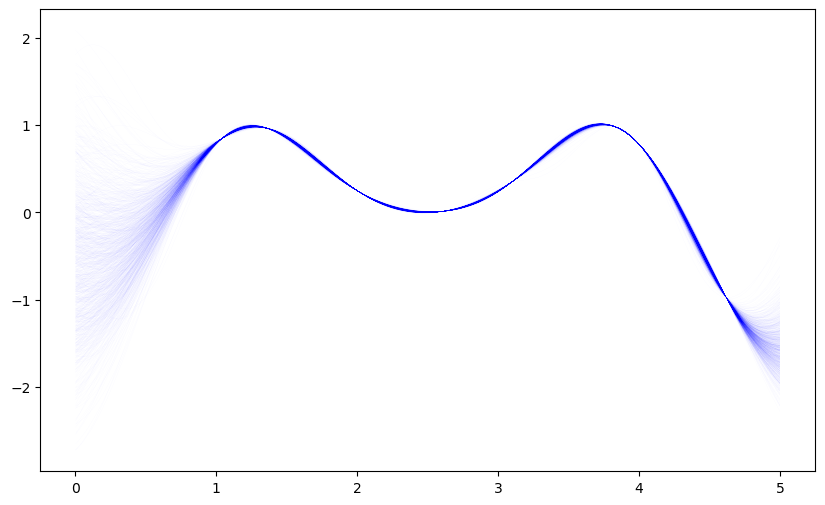

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.scatter(X, y, s=20, c='tab:red', zorder=10)
for chain in ynew:
    for draw in chain:
        plt.plot(Xnew.flatten(), draw, lw=.1, alpha=.05, c='black')